### EDA

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
data = pd.read_csv("../data/raw/orders.csv",parse_dates=['order_date'])


In [20]:
data.shape

(10000, 19)

In [21]:
data.sample(5)

,order_id,customer_id,order_date,category,region,order_value,payment_method,is_cod,discount_pct,is_high_discount,expected_delivery_days,delivery_days,delivery_delay,is_delivery_delayed,customer_previous_orders,customer_previous_returns,customer_return_rate,is_high_value,returned
5736,ORD1005736,CUST102161,2026-06-11,Beauty,North,1654.51,Card,0,24.9,0,4,5,1,0,4,1,0.25,0,0
1512,ORD1001512,CUST101882,2026-03-26,Toys,South,1348.89,COD,1,30.4,0,4,3,0,0,0,0,0.00,0,1
1641,ORD1001641,CUST101786,2026-03-29,Sports,West,2564.27,UPI,0,7.5,0,5,8,3,1,1,1,1.00,0,1
6325,ORD1006325,CUST100070,2026-06-21,Sports,East,4510.16,COD,1,21.4,0,4,6,2,1,0,0,0.00,0,0
1990,ORD1001990,CUST100511,2026-04-03,Home & Kitchen,West,10000.00,Wallet,0,10.4,0,3,1,0,0,1,0,0.00,1,0


In [22]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   order_id                   10000 non-null  object        
 1   customer_id                10000 non-null  object        
 2   order_date                 10000 non-null  datetime64[ns]
 3   category                   10000 non-null  object        
 4   region                     10000 non-null  object        
 5   order_value                10000 non-null  float64       
 6   payment_method             10000 non-null  object        
 7   is_cod                     10000 non-null  int64         
 8   discount_pct               10000 non-null  float64       
 9   is_high_discount           10000 non-null  int64         
 10  expected_delivery_days     10000 non-null  int64         
 11  delivery_days              10000 non-null  int64         
 12  deliv

### Analysis

In [23]:
data['returned'].value_counts()
# imbalance in the data

returned
0    7711
1    2289
Name: count, dtype: int64

In [25]:
print(data['order_value'].describe())
print(data['order_value'].skew())

count    10000.000000
mean      9759.876790
std      12638.600448
min        225.630000
25%       2341.855000
50%       4295.710000
75%      10000.000000
max      60000.000000
Name: order_value, dtype: float64
2.169563709338178


In [31]:
data['order_value'].quantile(0.98)

np.float64(51274.55180000006)

<Axes: ylabel='Density'>

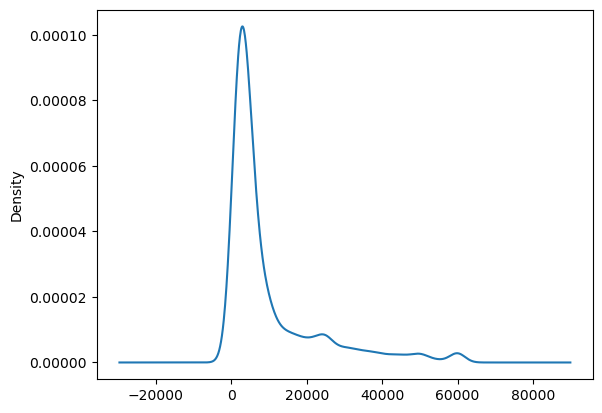

In [33]:
data['order_value'].plot(kind='kde')
# the data hass outliers but these are genuine orders value no need to remove or cap 
# the data has right skwed the impact in the distance base or formula base algo

In [41]:
data.groupby("returned")['order_value'].agg(['mean','median'])

,mean,median
returned,,
0,9929.555032,4308.72
1,9188.278309,4271.98


<Axes: xlabel='returned', ylabel='order_value'>

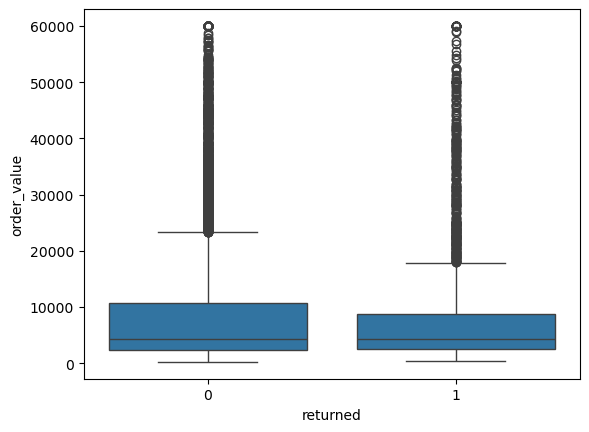

In [42]:
sns.boxplot(x="returned", y="order_value", data=data)

<Axes: xlabel='category'>

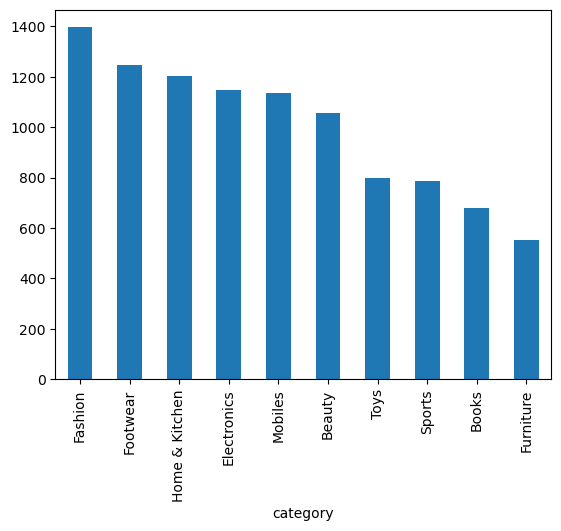

In [48]:
data['category'].value_counts().plot(kind='bar')

In [56]:
pd.crosstab(data['category'],data['returned'])
# sb se jada fashion footware walle return hote hai
# one hot encode

returned,0,1
category,,
Beauty,892,162
Books,633,47
Electronics,918,230
Fashion,836,560
Footwear,763,484
Furniture,426,127
Home & Kitchen,982,220
Mobiles,913,223
Sports,656,130


In [59]:
data['region'].value_counts()

region
South      2078
East       2033
West       1990
Central    1962
North      1937
Name: count, dtype: int64

In [61]:
pd.crosstab(data['region'],data['returned'])
# their is similare returned rate between the region

returned,0,1
region,,
Central,1521,441
East,1531,502
North,1490,447
South,1630,448
West,1539,451


In [63]:
data['payment_method'].value_counts()

payment_method
COD           3540
UPI           2882
Card          2077
NetBanking     795
Wallet         706
Name: count, dtype: int64

In [65]:
pd.crosstab(data['payment_method'],data['returned'])
# COD orders has high chances to return 

returned,0,1
payment_method,,
COD,2521,1019
Card,1648,429
NetBanking,651,144
UPI,2324,558
Wallet,567,139


In [66]:
pd.crosstab(data['is_cod'],data['returned'])

returned,0,1
is_cod,,
0,5190,1270
1,2521,1019


<Axes: ylabel='Frequency'>

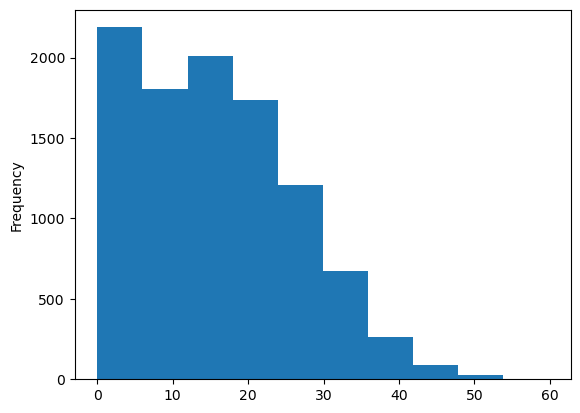

In [71]:
data['discount_pct'].plot(kind='hist')

In [72]:
data['discount_pct'].describe()

count    10000.000000
mean        15.581190
std         10.805504
min          0.000000
25%          7.175000
50%         15.000000
75%         23.000000
max         59.800000
Name: discount_pct, dtype: float64

In [74]:
data.groupby("returned")["discount_pct"].agg(
    ["mean", "median", "std", "min", "max","count"]
)

,mean,median,std,min,max,count
returned,,,,,,
0,15.534639,14.9,10.768837,0.0,58.5,7711
1,15.738008,15.2,10.929034,0.0,59.8,2289


In [77]:
pd.crosstab(data['expected_delivery_days'],data['returned'])

returned,0,1
expected_delivery_days,,
2,739,257
3,1933,562
4,3463,1039
5,1576,431


In [78]:
pd.crosstab(data['delivery_days'],data['returned'])

returned,0,1
delivery_days,,
1,867,201
2,885,197
3,1202,321
4,1400,364
5,1328,388
6,1007,357
7,565,219
8,296,148
9,106,67


In [79]:
pd.crosstab(data['delivery_delay'],data['returned'])

returned,0,1
delivery_delay,,
0,4093,956
1,1461,412
2,1076,407
3,647,280
4,288,143
5,111,65
6,28,23
7,5,3
8,1,0


In [80]:
pd.crosstab(data['is_delivery_delayed'],data['returned'])

returned,0,1
is_delivery_delayed,,
0,5554,1368
1,2157,921


In [82]:
data['customer_previous_orders'].value_counts()

customer_previous_orders
0     2459
1     2258
2     1900
3     1398
4      913
5      536
6      299
7      141
8       64
9       23
10       7
11       2
Name: count, dtype: int64

In [83]:
pd.crosstab(data['customer_previous_orders'],data['returned'])

returned,0,1
customer_previous_orders,,
0,2041,418
1,1711,547
2,1444,456
3,1046,352
4,679,234
5,393,143
6,219,80
7,102,39
8,51,13


In [84]:
data['customer_previous_returns'].value_counts()

customer_previous_returns
0    7099
1    1835
2     691
3     244
4      98
5      26
6       5
7       1
8       1
Name: count, dtype: int64

In [85]:
pd.crosstab(data['customer_previous_returns'],data['returned'])

returned,0,1
customer_previous_returns,,
0,5826,1273
1,1226,609
2,433,258
3,148,96
4,61,37
5,15,11
6,2,3
7,0,1
8,0,1


In [86]:
pd.crosstab(data['customer_return_rate'],data['returned'])

returned,0,1
customer_return_rate,,
0.000,5826,1273
0.091,1,0
0.100,1,0
0.111,4,0
0.125,10,0
0.143,28,11
0.167,72,22
0.200,133,48
0.222,3,2


In [87]:
pd.crosstab(data['is_high_value'],data['returned'])

returned,0,1
is_high_value,,
0,3859,1112
1,3852,1177


In [43]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   order_id                   10000 non-null  object        
 1   customer_id                10000 non-null  object        
 2   order_date                 10000 non-null  datetime64[ns]
 3   category                   10000 non-null  object        
 4   region                     10000 non-null  object        
 5   order_value                10000 non-null  float64       
 6   payment_method             10000 non-null  object        
 7   is_cod                     10000 non-null  int64         
 8   discount_pct               10000 non-null  float64       
 9   is_high_discount           10000 non-null  int64         
 10  expected_delivery_days     10000 non-null  int64         
 11  delivery_days              10000 non-null  int64         
 12  deliv